# Imports


In [1]:
%reload_ext autoreload
%autoreload 2

from dataclasses import replace
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt

def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "analog_qec").is_dir() and (candidate / "notebook").is_dir():
            return candidate
    raise RuntimeError("Could not find the analog-qec repository root")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from analog_qec.phenomenological_resource_estimate import (
    CrosstalkConfig,
    apply_plot_style,
    build_comparison_points,
    default_phenomenological_resource_estimate_config,
    default_plot_config,
    plot_phenomenological_resource_estimate,
    plot_stacked_phenomenological_resource_estimate,
)

plot_config = default_plot_config()
apply_plot_style(plot_config)

FIGURE_DIR = REPO_ROOT / "notebook" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Phenomenological resource estimate

This plot shows a phenomenological error probability $P_\mathrm{err}=1-e^{-H}$ on the x-axis while positioning points by the cumulative error exponent $H$ internally. The benchmark is specified by dimensionless angular analog evolution time $Jt$. Here a 25 ns interaction time means one full $2\pi$ rotation, so the physical time per unit $Jt$ is $25\,\mathrm{ns}/2\pi$. Raw uses this physical analog time directly. In the scalar configuration EPS multiplies it by `EPSConfig.time_overhead_factor`; in the lambda sweep below, the plotted lambda value is a penalty parameter and the slowdown is $1+\lambda$. Surface code and STAR use an optimistic edge-colored Trotterization of the same $Jt$.

The default y-axis values include the measurement overhead for an observable-estimation task rather than only one circuit attempt. The task is final XY energy density plus radial transverse correlations, measured in global X and global Y bases. The default shot count is computed from the bounded-estimator rule $N_\mathrm{shots/basis}=\lceil\mathrm{Var}/\epsilon^2\rceil$ with $\mathrm{Var}\le1$ and $\epsilon=10^{-2}$, giving 10,000 shots per basis and 20,000 circuit executions total. Space-only plots are unaffected by this multiplier; time and space-time plots multiply the single-shot circuit time by the task shot count. Set `comparison_config.observable_task.enabled=False` to recover single-shot/per-attempt costs.

For Raw, EPS, and surface-code lifetime branches, the exponent uses an observable-sensitivity factor $n_\mathrm{eff}$ rather than automatically using the full 50-site register: $H=n_\mathrm{eff}T_\mathrm{err}/T_2$. This is not an assumption that errors spread instantly to every spin. It is a phenomenological proxy for how many independently located faults can noticeably perturb the chosen averaged observables. For energy density alone, the natural local scale is the average lattice degree $2|E|/n=170/50\approx3.4$, so $n_\mathrm{eff}\approx4$ is a useful optimistic setting. Because the current task also includes radial transverse correlations, the default uses $n_\mathrm{eff}=10$. Setting $n_\mathrm{eff}=50$ recovers the conservative register-survival interpretation in which any qubit error spoils the shot. This scalar $n_\mathrm{eff}$ model is not copied directly from a paper; it is motivated by observable-sensitive simulation analyses such as [Granet and Dreyer's error-dilution picture](https://doi.org/10.1103/PRXQuantum.6.010333) for local observables, [Trivedi, Rubio, and Cirac's stability analysis](https://doi.org/10.1038/s41467-024-50750-x) for local intensive observables in noisy analog simulators, and [Yu, Xu, and Zhao's observable-driven product-formula bounds](https://doi.org/10.1038/s42005-025-02260-5). In the raw analog case $T_2$ is dominated by pure dephasing, so we label the swept parameter as $T_\phi$. In the EPS case the default assumes pure dephasing is removed, so the limiting value is $T_2=2T_1$ and the plotted EPS labels quote the corresponding $T_1$.

Optional crosstalk controls add an extra Raw/EPS exponent term without changing the default figure. Crosstalk strengths are normalized as fractional Hamiltonian errors $\epsilon=J_\mathrm{xtalk}/J_\mathrm{nom}$, where $J_\mathrm{nom}=2\pi/t_{2\pi}$ and the default benchmark has $J_\mathrm{nom}T_\mathrm{analog}=20\cdot2\pi$. Static crosstalk represents always-on coherent terms whose accumulated angle shrinks when runtime is shortened. Drive-induced crosstalk scales with the intended control amplitude, so it does not necessarily improve when Raw runs faster by increasing coupling. The notebook uses the same monotone twirled-envelope proxy documented in the audit, $p_\mathrm{xtalk}=(1-e^{-\theta^2/2})/2$, and adds $H_\mathrm{xtalk}=n_{\mathrm{eff,xtalk}}p_\mathrm{xtalk}$ to the coherence exponent when `enable_crosstalk=True`.

For the surface-code baseline, the single-shot time factor is circuit depth, not total T count: T gates on different edges/registers are parallelized into edge-color and synthesis-depth layers. The total T count is used only to size an optimistic magic-state factory area, with no routing overhead or factory-induced stalls. STAR is plotted as a partial-FTQC literature baseline: it keeps the same Trotterized Pauli-rotation structure as the surface-code branch, but directly implements arbitrary rotations through injected analog-rotation states instead of Clifford+T synthesis and magic-state distillation. Its full-register operation exponent is $H_{\mathrm{STAR,full}}=H_{\mathrm{rot,full}}+H_{\mathrm{Cliff,full}}$, with $H_{\mathrm{rot,full}}=N_\mathrm{rot}/N_\mathrm{rot,budget}$ and $N_\mathrm{rot,budget}=1/[2(2p/15)]$ matching the STAR paper's two-RUS-step average. The plotted observable proxy applies the same sensitivity factor as the other architectures, $H_\mathrm{STAR}=(n_\mathrm{eff}/n_\mathrm{logical})H_{\mathrm{STAR,full}}$, while retaining the unscaled full-register components in metadata. The Clifford term uses the paper's fitted logical-round scaling for $d=3,5,7,9$ as a sensitivity estimate, and we show STAR traces for $p=5\times10^{-5}$, $p=10^{-4}$, and $p=5\times10^{-4}$. All STAR points use the same 50-site benchmark; the d=9 point has 12,960 physical qubits in the compact-block model.


## Benchmark, Raw, and EPS overrides

Edit the values below to choose the Raw dephasing-time points and EPS T1 curves. Values are in microseconds; the EPS backend uses T2=2*T1. The Raw T1-limit reference lines follow the EPS curve values by default.


In [27]:
# Dimensionless angular evolution time Jt. The default is 20 full 2*pi rotations.
simulated_Jt = 20 * 2 * math.pi

# Raw analog dephasing-time points. These labels use T_phi in microseconds.
raw_T_phi_values_us = (5, 25)

# Raw label offsets are Matplotlib offset points keyed by T_phi in us.
raw_T_phi_label_offsets = {
    5: (15, -10),
    25: (5, -10),
}

# EPS curve labels use these T1 values; EPSConfig receives T2=2*T1.
eps_T1_curve_values_us = (100, 500)

# EPS T1 curve label offsets are Matplotlib offset points keyed by T1 in us.
eps_T1_label_offsets_by_metric = {
    "space": {
        100: (5, 0),
        500: (0, 10),
    },
    "time": {
        100: (5, 0),
        500: (0, 10),
    },
}

# Keep the Raw T1-limit reference lines aligned with the EPS curves.
# Override separately here if you want a different reference set.
raw_T1_limit_values_us = eps_T1_curve_values_us

# EPS lambda label offsets are Matplotlib offset points keyed by lambda value.
eps_lambda_label_offsets = {
    0.1: (7, -6),
    0.25: (-9, -5),
    0.5: (-17, 0),
    1: (-14, 1),
    2: (-13, 3),
    5: (-11, 4),
}


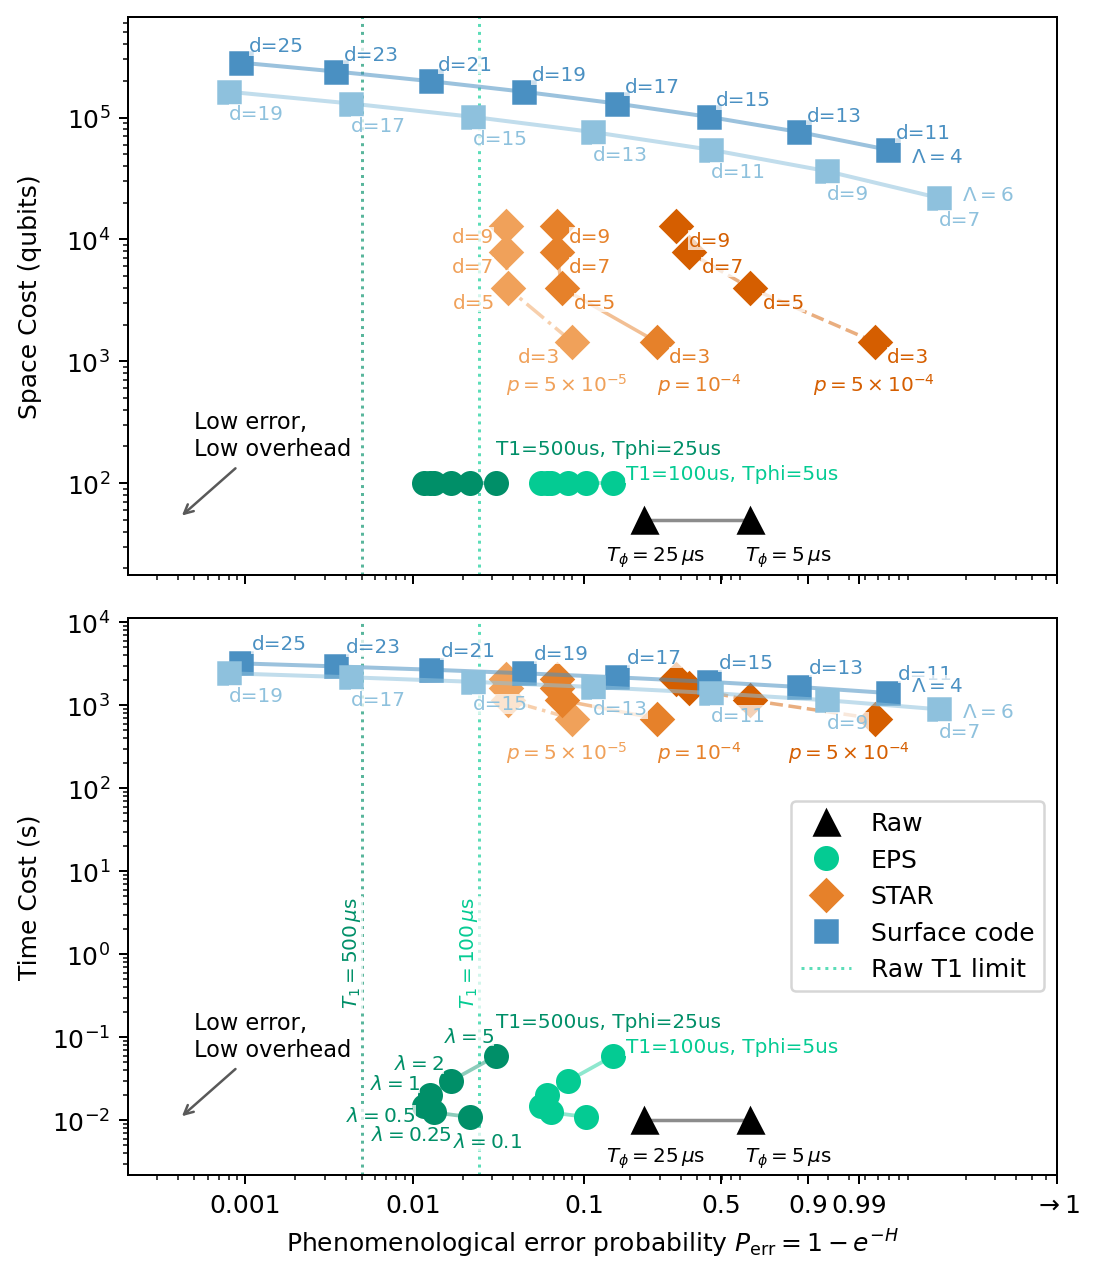

In [28]:
comparison_config = default_phenomenological_resource_estimate_config()
simulated_Jt = globals().get("simulated_Jt", comparison_config.benchmark.Jt)
raw_T_phi_values_us = globals().get(
    "raw_T_phi_values_us", comparison_config.raw.T_phi_values_us
)
if isinstance(raw_T_phi_values_us, (int, float)):
    raw_T_phi_values_us = (raw_T_phi_values_us,)
else:
    raw_T_phi_values_us = tuple(raw_T_phi_values_us)
raw_T_phi_label_offsets = dict(globals().get("raw_T_phi_label_offsets", {}))
eps_T1_curve_values_us = tuple(
    globals().get(
        "eps_T1_curve_values_us",
        tuple(T2_us / 2 for T2_us in comparison_config.eps.T2_values_us),
    )
)
raw_T1_limit_values_us = tuple(
    globals().get("raw_T1_limit_values_us", eps_T1_curve_values_us)
)
eps_T2_curve_values_us = tuple(2 * T1_us for T1_us in eps_T1_curve_values_us)
# EPS residual pure-dephasing controls. Set T_phi to None to disable this term.
# Default task: Var <= 1, epsilon = 1e-2, two bases -> 20,000 shots.
# Error-sensitivity choices: 4 for energy density only, 10 for the current
# energy-density plus radial-correlator task, 50 for strict register survival.
n_eff_observable = 10
# EPS penalty sweep: each lambda-sweep point runs with slowdown 1 + lambda.
# Scalar lambda values below set fallback suppression factors when
# eps_lambda_values is empty; they are not wired to EPS runtime.
eps_scalar_crosstalk_lambda = 1
eps_scalar_dephasing_lambda = 1
eps_lambda_values = (0.1, 0.25, 0.5, 1, 2, 5)
# Vertical Raw relaxation-limit references use T2=2*T1 at the Raw runtime.
raw_T1_limit_include_crosstalk = False

eps_dephasing_T_phi_us = [5, 25]  # Scalar, or list matching eps_T1_curve_values_us.

# Optional Raw/EPS coherent-crosstalk envelope. Disabled by default.
# Ratios are normalized to the nominal simulation coupling J_nom=2*pi/t_2pi.
enable_crosstalk = True
static_crosstalk_ratio = 0.0
drive_induced_crosstalk_ratio_at_unit_scale = 0.001
raw_crosstalk_control_scale = None  # None -> 1 / raw.time_overhead_factor
eps_crosstalk_control_scale = 1.0

delta = 50

def eps_crosstalk_suppression_for_lambda(lambda_value):
    scale = (1 + lambda_value * delta)
    return (2 / 3) * (1 / (scale**2)) + (1 / 3) * (1 / (scale))


def eps_dephasing_suppression_for_lambda(lambda_value):
    scale = (1 + lambda_value * delta)
    return (2 / 3) * (1 / (scale**2)) + (1 / 3) * (1 / (scale))


eps_crosstalk_suppression = eps_crosstalk_suppression_for_lambda(
    eps_scalar_crosstalk_lambda
)
eps_crosstalk_suppression_by_lambda = {
    lambda_value: eps_crosstalk_suppression_for_lambda(lambda_value)
    for lambda_value in eps_lambda_values
}
eps_dephasing_suppression = (
    eps_dephasing_suppression_for_lambda(eps_scalar_dephasing_lambda)
    if eps_dephasing_T_phi_us is not None
    else 0.0
)
eps_dephasing_suppression_by_lambda = (
    {
        lambda_value: eps_dephasing_suppression_for_lambda(lambda_value)
        for lambda_value in eps_lambda_values
    }
    if eps_dephasing_T_phi_us is not None
    else {}
)
xtalk_sensitivity_factor = None  # None -> n_eff_observable
# Example sensitivity point: static_crosstalk_ratio = 1e-3 gives
# theta = 1e-3 * 20 * 2*pi at the default raw runtime.

comparison_config = replace(
    comparison_config,
    benchmark=replace(
        comparison_config.benchmark,
        Jt=simulated_Jt,
    ),
    observable_task=replace(
        comparison_config.observable_task,
        error_sensitivity_qubits=n_eff_observable,
    ),
    raw=replace(
        comparison_config.raw,
        T_phi_values_us=raw_T_phi_values_us,
    ),
    eps=replace(
        comparison_config.eps,
        lambda_values=eps_lambda_values,
        T2_values_us=eps_T2_curve_values_us,
        dephasing_T_phi_us=eps_dephasing_T_phi_us,
        dephasing_suppression_factor=eps_dephasing_suppression,
        dephasing_suppression_factor_by_lambda=eps_dephasing_suppression_by_lambda,
    ),
    crosstalk=CrosstalkConfig(
        enabled=enable_crosstalk,
        static_crosstalk_ratio=static_crosstalk_ratio,
        drive_induced_crosstalk_ratio_at_unit_scale=(
            drive_induced_crosstalk_ratio_at_unit_scale
        ),
        raw_control_scale_factor=raw_crosstalk_control_scale,
        eps_control_scale_factor=eps_crosstalk_control_scale,
        eps_suppression_factor=eps_crosstalk_suppression,
        eps_suppression_factor_by_lambda=eps_crosstalk_suppression_by_lambda,
        sensitivity_factor=xtalk_sensitivity_factor,
    ),
)
# To recover single-shot/per-attempt costs, uncomment:
# comparison_config = replace(
#     comparison_config,
#     observable_task=replace(comparison_config.observable_task, enabled=False),
# )
comparison_points = build_comparison_points(comparison_config)
# len(comparison_points)

plot_config = replace(
    default_plot_config(),
    raw_T1_limit_values_us=raw_T1_limit_values_us,
    raw_T1_limit_include_crosstalk=raw_T1_limit_include_crosstalk,
)
# Optional notebook-only tweaks to config.py defaults go here.
plot_config.eps_curve_label_offsets_by_metric["space"].update(
    eps_T1_label_offsets_by_metric["space"]
)
plot_config.eps_curve_label_offsets_by_metric["time"].update(
    eps_T1_label_offsets_by_metric["time"]
)
plot_config.eps_lambda_label_offsets.update(eps_lambda_label_offsets)
plot_config.raw_annotation_offsets.update(
    {
        rf"Raw $T_\phi={T_phi:g}\,\mu\mathrm{{s}}$": offset
        for T_phi, offset in raw_T_phi_label_offsets.items()
    }
)
plot_config.star_p_label_offsets_by_metric["space"].update({
    5e-5: (0, -58),
    1e-4: (40, -58),
    5e-4: (55, -58),
})
# plot_config.star_p_label_offsets_by_metric["time"].update({
#     5e-5: (0, -50),
#     1e-4: (40, -50),
#     5e-4: (45, -50),
# })
# plot_config.surface_distance_label_offsets_by_metric["space"].update({
#     2: (4, 2),
#     4: (3, 3),
#     6: (0, -5),
# })
# plot_config.surface_distance_label_offsets_by_metric["time"].update({
#     2: (4, 2),
#     4: (4, 8),
#     6: (0, -10),
# })
# plot_config.lambda_label_offsets_by_metric["space"].update({
#     2: (30, 0),
#     4: (30, 1),
#     6: (30, 8),
# })
# plot_config.lambda_label_offsets_by_metric["time"].update({
#     2: (30, 0),
#     4: (30, 10),
#     6: (30, -8),
# })
apply_plot_style(plot_config)

figure_outputs = {
    "space_time": "figure_5_resource_estimation.pdf",
    "space": "figure_5_resource_estimation_space_cost.pdf",
    "time": "figure_5_resource_estimation_time_cost.pdf",
}

# for y_metric, filename in figure_outputs.items():
#     fig, ax = plot_phenomenological_resource_estimate(
#         comparison_points,
#         plot_config=plot_config,
#         y_metric=y_metric,
#     )
#     output_path = FIGURE_DIR / filename
#     fig.savefig(output_path, format="pdf", bbox_inches="tight")
#     plt.show()

# Use any subset of ("space_time", "space", "time") here.
stacked_y_metrics = ("space", "time")
fig, axes = plot_stacked_phenomenological_resource_estimate(
    comparison_points,
    plot_config=plot_config,
    y_metrics=stacked_y_metrics,
)
output_path = FIGURE_DIR / "figure_5_resource_estimation_stacked.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()

# Inspect Raw/EPS crosstalk decomposition after enabling crosstalk:
# [
#     {
#         key: point.as_dict()[key]
#         for key in (
#             "label",
#             "H",
#             "H_coherence",
#             "H_crosstalk",
#             "xtalk_theta_rad",
#             "xtalk_p_proxy",
#         )
#     }
#     for point in comparison_points
#     if point.scheme in {"Raw", "EPS"}
# ]
